# Exploratory data analysis

**CST4275 Master's Individual Thesis — Swetank Mohanty (M01087647)**
Supervisor: Dr Siddhaling Urolagin, Middlesex University Dubai

This notebook profiles both layers of the data:

- **Part A — raw sources.** The four Kaggle corpora under `datasets/raw`, examined for the
  defects that motivated the design of `scripts/build_dataset.py`. Every file over a few hundred
  megabytes is read with a streaming scan, so nothing here loads a 933 MB CSV into memory.
- **Part B — the processed dataset.** `movies_merged`, produced by the build pipeline, examined
  for coverage, feature distributions and the properties that constrain the three recommender
  modules.

Run it top to bottom. Part A can be skipped with the `RUN_RAW` switch if the raw corpora are not
present on this machine; Part B needs only `datasets/processed`.

## 0. Setup

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "figure.autolayout": True,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "axes.edgecolor": "#666666",
    "font.size": 10,
})

# One accent per semantic role, reused throughout so figures read as a set.
INK, ACCENT, MUTED = "#1F3864", "#4472C4", "#A6A6A6"
POS, NEG = "#2E7D5B", "#B4462F"
SEQ = "mako"

print(f"python {sys.version.split()[0]} | polars {pl.__version__} | pandas {pd.__version__}")

python 3.12.13 | polars 1.43.0 | pandas 2.3.3


In [2]:
def find_project_root(marker: str = "datasets") -> Path:
    """Walk upwards until the folder containing `datasets` is found.

    Lets the notebook run from `notebooks/`, from the repository root, or from
    Jupyter started anywhere inside the tree.
    """
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"no ancestor of {here} contains a {marker!r} directory")


ROOT = find_project_root()
RAW = ROOT / "datasets" / "raw"
PROC = ROOT / "datasets" / "processed"
FIGS = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

RUN_RAW = RAW.is_dir() and any(RAW.iterdir())

print(f"project root : {ROOT}")
print(f"raw layer    : {RAW}  (present: {RUN_RAW})")
print(f"processed    : {PROC}  (present: {PROC.is_dir()})")

project root : D:\Middlesex University Dubai\CST4275\cb-movies-recommender
raw layer    : D:\Middlesex University Dubai\CST4275\cb-movies-recommender\datasets\raw  (present: True)
processed    : D:\Middlesex University Dubai\CST4275\cb-movies-recommender\datasets\processed  (present: True)


In [3]:
LIST_COLUMNS = (
    "genres", "keywords", "cast_top", "directors",
    "production_companies", "production_countries", "spoken_languages", "ml_tags",
)


def load_table(stem: str, *, base: Path = None, separator: str = "|",
               lazy: bool = False):
    """Load a build artefact, preferring Parquet and falling back to CSV.

    The pipeline defaults to CSV, which cannot store nested columns, so the eight
    list columns arrive as `separator`-delimited strings. This re-splits them so
    downstream code sees the same dtypes either way. Parquet needs no repair.
    """
    base = base or PROC
    parquet, csv = base / f"{stem}.parquet", base / f"{stem}.csv"

    if parquet.exists():
        frame = pl.scan_parquet(parquet) if lazy else pl.read_parquet(parquet)
        source = "parquet"
    elif csv.exists():
        frame = pl.scan_csv(csv, infer_schema_length=10_000) if lazy \
            else pl.read_csv(csv, infer_schema_length=10_000)
        present = [c for c in LIST_COLUMNS if c in frame.collect_schema().names()]
        if present:
            frame = frame.with_columns([
                pl.when(pl.col(c).is_null() | (pl.col(c) == ""))
                  .then(pl.lit([], dtype=pl.List(pl.String)))
                  .otherwise(pl.col(c).str.split(separator))
                  .alias(c)
                for c in present
            ])
        source = "csv (list columns re-split)"
    else:
        raise FileNotFoundError(f"neither {parquet.name} nor {csv.name} in {base}")

    print(f"loaded {stem} from {source}")
    return frame


def require(*paths: Path, label: str = "") -> bool:
    """Return True when every path exists, otherwise explain what is missing.

    The raw corpora total ~4.7 GB and are not committed to the repository, so a
    clone without them should skip Part A cleanly rather than raise.
    """
    missing = [p for p in paths if not Path(p).exists()]
    if missing:
        names = ", ".join(Path(m).name for m in missing)
        print(f"skipped{' ' + label if label else ''} — file(s) not present: {names}")
        return False
    return True


def save_fig(fig, name: str) -> None:
    """Write a figure to outputs/figures so it can be pulled into the thesis."""
    path = FIGS / f"{name}.png"
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    print(f"  saved {path.relative_to(ROOT)}")


def thousands(axis) -> None:
    axis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

---
# Part A — the raw sources

Everything in this part reads from `datasets/raw`. The point is not to admire the data but to
find the specific defects a merge has to survive: corrupt identifiers, duplicate keys, empty
arrays that look populated, and identifier systems that only partly overlap.

## A1. File inventory

In [4]:
if RUN_RAW:
    rows = []
    for path in sorted(RAW.rglob("*.csv")):
        # Row counts come from a streaming scan: no file is held in memory.
        n = pl.scan_csv(path, infer_schema_length=0).select(pl.len()).collect().item()
        rows.append({
            "corpus": path.parent.name,
            "file": path.name,
            "MB": round(path.stat().st_size / 1024**2, 1),
            "rows": n,
        })
    inventory = pd.DataFrame(rows).sort_values(["corpus", "MB"], ascending=[True, False])
    display(inventory.reset_index(drop=True))
    print(f"\ntotal: {inventory.MB.sum():,.0f} MB across {len(inventory)} files, "
          f"{inventory.rows.sum():,} rows")
else:
    print("raw layer absent — skipping Part A")

,corpus,file,MB,rows
0,movielens-full,ratings.csv,724.0,27753444
1,movielens-full,genome-scores.csv,395.6,14862528
2,movielens-full,tags.csv,37.9,1108997
3,movielens-full,movies.csv,2.7,58098
4,movielens-full,links.csv,1.2,58098
5,movielens-full,genome-tags.csv,0.0,1128
6,movielens-latest,ratings.csv,890.6,33832162
7,movielens-latest,genome-scores.csv,497.4,18472128
8,movielens-latest,tags.csv,81.4,2328315
9,movielens-latest,movies.csv,4.0,86537



total: 4,203 MB across 22 files, 126,455,740 rows


## A2. Quality audit of `movies_metadata.csv`

This is the richest source and the only one carrying cast and crew, so its defects propagate
furthest. Read with type inference disabled: three rows are structurally corrupt and shift
fields sideways, which derails inference and silently nulls whole columns.

In [5]:
META_PATH = RAW / "the-movies-dataset" / "movies_metadata.csv"
if RUN_RAW and require(META_PATH, label="movies_metadata audit"):
    meta = pl.read_csv(
        META_PATH,
        infer_schema_length=0, ignore_errors=True, truncate_ragged_lines=True,
    )
    typed = meta.with_columns(pl.col("id").cast(pl.Int64, strict=False).alias("tmdb_id"))
    corrupt = typed.filter(pl.col("tmdb_id").is_null())

    audit = {
        "rows read": meta.height,
        "non-numeric id (corrupt)": corrupt.height,
        "duplicate tmdb ids": typed.drop_nulls("tmdb_id").height
                              - typed.drop_nulls("tmdb_id")["tmdb_id"].n_unique(),
        "null/blank overview": int((meta["overview"].fill_null("").str.strip_chars() == "").sum()),
        "empty genres '[]'": int((meta["genres"] == "[]").sum()),
        "null imdb_id": int(meta["imdb_id"].null_count()),
        "runtime 0 or null": int((meta["runtime"].cast(pl.Float64, strict=False)
                                  .fill_null(0) == 0).sum()),
        "status != Released": int((meta["status"] != "Released").sum()),
        "adult == True": int((meta["adult"].str.to_lowercase() == "true").sum()),
        "video == True": int((meta["video"].str.to_lowercase() == "true").sum()),
    }
    display(pd.Series(audit, name="count").to_frame())
    print("\ncorrupt id values:", corrupt["id"].to_list())

,count
rows read,45466
non-numeric id (corrupt),3
duplicate tmdb ids,30
null/blank overview,959
empty genres '[]',2442
null imdb_id,17
runtime 0 or null,1821
status != Released,365
adult == True,9
video == True,93



corrupt id values: ['1997-08-20', '2012-09-29', '2014-01-01']


In [6]:
CRED_PATH = RAW / "the-movies-dataset" / "credits.csv"
KW_PATH = RAW / "the-movies-dataset" / "keywords.csv"
if RUN_RAW and require(CRED_PATH, KW_PATH, label="credits/keywords"):
    creds = pl.read_csv(CRED_PATH, infer_schema_length=0)
    kws = pl.read_csv(KW_PATH, infer_schema_length=0)

    companion = pd.DataFrame([
        {"file": "credits.csv", "rows": creds.height,
         "duplicate ids": creds.height - creds["id"].n_unique(),
         "empty cast []": int((creds["cast"] == "[]").sum()),
         "empty crew []": int((creds["crew"] == "[]").sum())},
        {"file": "keywords.csv", "rows": kws.height,
         "duplicate ids": kws.height - kws["id"].n_unique(),
         "empty cast []": None,
         "empty crew []": None},
    ])
    display(companion)

    empty_kw = int((kws["keywords"] == "[]").sum())
    print(f"\nempty keyword arrays: {empty_kw:,} of {kws.height:,} "
          f"({empty_kw / kws.height:.1%})")
    print("This is the single most consequential sparsity in the raw layer: the metadata")
    print("recommender is specified over keywords, and a third of rows have none.")

,file,rows,duplicate ids,empty cast [],empty crew []
0,credits.csv,45476,44,2418.0,771.0
1,keywords.csv,46419,987,NaN,NaN



empty keyword arrays: 14,795 of 46,419 (31.9%)
This is the single most consequential sparsity in the raw layer: the metadata
recommender is specified over keywords, and a third of rows have none.


## A3. The two MovieLens snapshots

Despite the folder names, `movielens-full` is the **older** extract. The names come from the
Kaggle slugs used by the download script, not from the contents. Before the two can be unioned,
they have to be shown not to disagree.

In [7]:
ML_FILES = [RAW / f / n for f in ("movielens-full", "movielens-latest")
            for n in ("movies.csv", "links.csv")]
if RUN_RAW and require(*ML_FILES, label="MovieLens snapshot comparison"):
    def read_ml(folder: str) -> tuple[pl.DataFrame, pl.DataFrame]:
        movies = pl.read_csv(RAW / folder / "movies.csv", infer_schema_length=0).with_columns(
            pl.col("movieId").cast(pl.Int32, strict=False))
        links = pl.read_csv(RAW / folder / "links.csv", infer_schema_length=0).with_columns(
            pl.col("movieId").cast(pl.Int32, strict=False),
            pl.col("tmdbId").cast(pl.Float64, strict=False).cast(pl.Int32, strict=False))
        return movies, links

    m_full, l_full = read_ml("movielens-full")
    m_late, l_late = read_ml("movielens-latest")

    ids_full, ids_late = set(m_full["movieId"]), set(m_late["movieId"])
    overlap = pd.Series({
        "movielens-full": len(ids_full),
        "movielens-latest": len(ids_late),
        "shared": len(ids_full & ids_late),
        "full only": len(ids_full - ids_late),
        "latest only": len(ids_late - ids_full),
        "union": len(ids_full | ids_late),
    }, name="films")
    display(overlap.to_frame())

    # Are the shared rows actually consistent? This is what licenses the union.
    joined = m_full.join(m_late, on="movieId", suffix="_late")
    linked = l_full.join(l_late, on="movieId", suffix="_late")
    print(f"\nconsistency across {joined.height:,} shared films")
    print(f"  title mismatches  : {int((joined['title'] != joined['title_late']).sum())}")
    print(f"  genre mismatches  : {int((joined['genres'] != joined['genres_late']).sum())}")
    print(f"  imdbId mismatches : {int((linked['imdbId'] != linked['imdbId_late']).sum())}")
    both = linked.filter(pl.col("tmdbId").is_not_null() & pl.col("tmdbId_late").is_not_null())
    print(f"  tmdbId conflicts  : {int((both['tmdbId'] != both['tmdbId_late']).sum())}"
          f"  ({int((both['tmdbId'] != both['tmdbId_late']).sum()) / both.height:.2%})")
    recoverable = linked.filter(pl.col("tmdbId_late").is_null() & pl.col("tmdbId").is_not_null())
    print(f"  tmdbId present only in the older file: {recoverable.height:,}")

,films
movielens-full,58098
movielens-latest,86537
shared,55457
full only,2641
latest only,31080
union,89178



consistency across 55,457 shared films
  title mismatches  : 0
  genre mismatches  : 0
  imdbId mismatches : 0
  tmdbId conflicts  : 37  (0.07%)
  tmdbId present only in the older file: 1


  saved outputs\figures\a3_catalogue_union.png


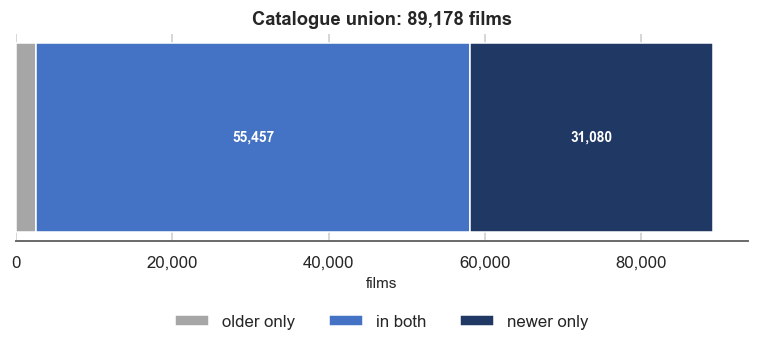

In [8]:
if RUN_RAW and "ids_full" in dir():
    fig, ax = plt.subplots(figsize=(7, 3.2))
    seg = [len(ids_full - ids_late), len(ids_full & ids_late), len(ids_late - ids_full)]
    labels = ["older only", "in both", "newer only"]
    left = 0
    for value, label, colour in zip(seg, labels, [MUTED, ACCENT, INK]):
        ax.barh(0, value, left=left, color=colour, edgecolor="white", label=label)
        if value > 3000:
            ax.text(left + value / 2, 0, f"{value:,}", ha="center", va="center",
                    color="white", fontsize=9, fontweight="semibold")
        left += value
    ax.set_yticks([])
    ax.set_xlabel("films")
    thousands(ax.xaxis)
    ax.set_title(f"Catalogue union: {sum(seg):,} films")
    ax.legend(frameon=False, ncols=3, loc="upper center", bbox_to_anchor=(0.5, -0.28))
    sns.despine(left=True)
    save_fig(fig, "a3_catalogue_union")
    plt.show()

## A4. Identifier linkage

In [9]:
if RUN_RAW and {"typed", "l_full"} <= set(dir()):
    content_ids = set(typed.drop_nulls("tmdb_id")["tmdb_id"].to_list())

    link_rows = []
    for name, links in [("movielens-full", l_full), ("movielens-latest", l_late)]:
        tmdb = links["tmdbId"].drop_nulls().unique()
        hit = int(tmdb.is_in(list(content_ids)).sum())
        link_rows.append({"catalogue": name, "distinct tmdbId": len(tmdb),
                          "resolves into movies_metadata": hit,
                          "rate": f"{hit / len(tmdb):.1%}"})
    display(pd.DataFrame(link_rows))
    print("\nThe newer catalogue is far larger but resolves at roughly half the rate: it holds")
    print("thousands of films released after The Movies Dataset was published in 2017.")
    print("That gap is exactly what the tier-2 TMDB dump exists to close.")

,catalogue,distinct tmdbId,resolves into movies_metadata,rate
0,movielens-full,57877,45410,78.5%
1,movielens-latest,86374,42985,49.8%



The newer catalogue is far larger but resolves at roughly half the rate: it holds
thousands of films released after The Movies Dataset was published in 2017.
That gap is exactly what the tier-2 TMDB dump exists to close.


## A5. Ratings at scale

The ratings file is the largest input. Everything below is computed with `scan_csv` and a
streaming collect, so peak memory stays flat regardless of file size.

In [10]:
RATINGS_SCHEMA = {"userId": pl.Int32, "movieId": pl.Int32,
                  "rating": pl.Float32, "timestamp": pl.Int64}

ratings_path = next((p for p in [RAW / "movielens-latest" / "ratings.csv",
                                 RAW / "movielens-full" / "ratings.csv"]
                    if p.exists()), None)
if RUN_RAW and ratings_path is None:
    print("skipped ratings analysis — no ratings.csv under either MovieLens folder")

if RUN_RAW and ratings_path is not None:
    lf = pl.scan_csv(ratings_path, schema_overrides=RATINGS_SCHEMA)
    summary = lf.select(
        pl.len().alias("ratings"),
        pl.col("userId").n_unique().alias("users"),
        pl.col("movieId").n_unique().alias("films"),
        pl.col("rating").mean().alias("mean"),
        pl.col("rating").median().alias("median"),
        pl.col("rating").std().alias("std"),
        pl.from_epoch(pl.col("timestamp").min(), time_unit="s").alias("first"),
        pl.from_epoch(pl.col("timestamp").max(), time_unit="s").alias("last"),
    ).collect(engine="streaming")
    display(summary.to_pandas().T.rename(columns={0: ratings_path.parent.name}))

    density = summary["ratings"][0] / (summary["users"][0] * summary["films"][0])
    print(f"\nmatrix density: {density:.2e}  "
          f"({summary['ratings'][0]:,} of {summary['users'][0] * summary['films'][0]:,} cells)")
    print("Sparsity at this level is precisely why a content-based approach is worth building:")
    print("collaborative signal is unavailable for most (user, film) pairs.")

,movielens-latest
ratings,33832162
users,330975
films,83239
mean,3.54254
median,4.0
std,1.063959
first,1995-01-09 11:46:44
last,2023-07-20 08:53:33



matrix density: 1.23e-03  (33,832,162 of 27,550,028,025 cells)
Sparsity at this level is precisely why a content-based approach is worth building:
collaborative signal is unavailable for most (user, film) pairs.


  saved outputs\figures\a5_ratings_distributions.png


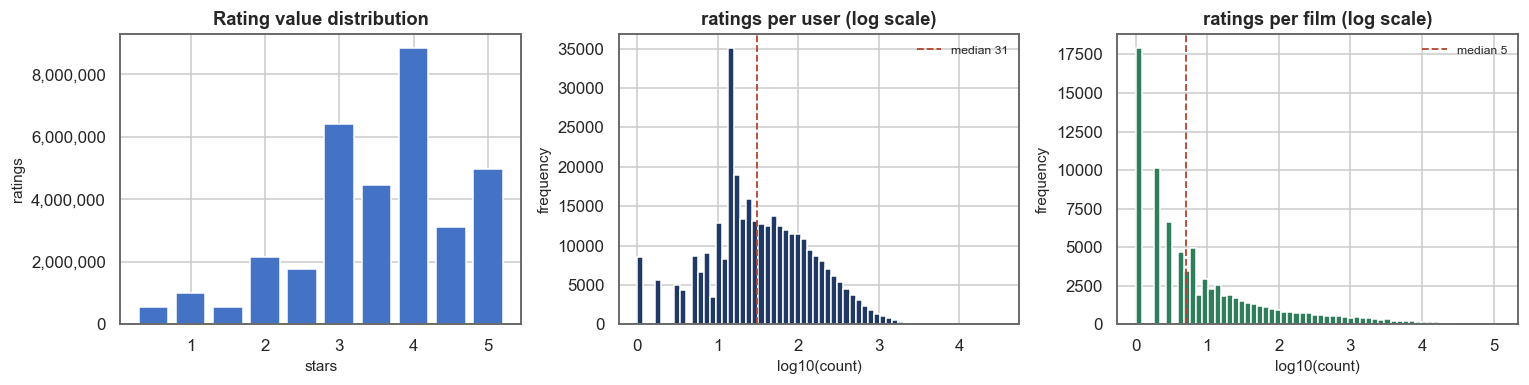

half-star ratings introduced later: 31.0% of all ratings
most-rated film has 122,296 ratings; 61.5% of films have fewer than 10


In [11]:
if RUN_RAW and ratings_path is not None:
    dist = (lf.group_by("rating").len().sort("rating").collect(engine="streaming")
              .to_pandas())
    per_user = (lf.group_by("userId").len().select(pl.col("len"))
                  .collect(engine="streaming")["len"].to_numpy())
    per_film = (lf.group_by("movieId").len().select(pl.col("len"))
                  .collect(engine="streaming")["len"].to_numpy())

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

    axes[0].bar(dist["rating"], dist["len"], width=0.4, color=ACCENT)
    axes[0].set_title("Rating value distribution")
    axes[0].set_xlabel("stars"); axes[0].set_ylabel("ratings")
    thousands(axes[0].yaxis)

    for ax, data, label, colour in [
        (axes[1], per_user, "ratings per user", INK),
        (axes[2], per_film, "ratings per film", POS),
    ]:
        ax.hist(np.log10(np.clip(data, 1, None)), bins=60, color=colour)
        ax.set_title(f"{label} (log scale)")
        ax.set_xlabel("log10(count)"); ax.set_ylabel("frequency")
        ax.axvline(np.log10(np.median(data)), color=NEG, ls="--", lw=1.2,
                   label=f"median {np.median(data):,.0f}")
        ax.legend(frameon=False, fontsize=8)

    save_fig(fig, "a5_ratings_distributions")
    plt.show()

    print(f"half-star ratings introduced later: "
          f"{dist[dist.rating % 1 != 0]['len'].sum() / dist['len'].sum():.1%} of all ratings")
    print(f"most-rated film has {per_film.max():,} ratings; "
          f"{(per_film < 10).mean():.1%} of films have fewer than 10")

  saved outputs\figures\a5_ratings_over_time.png


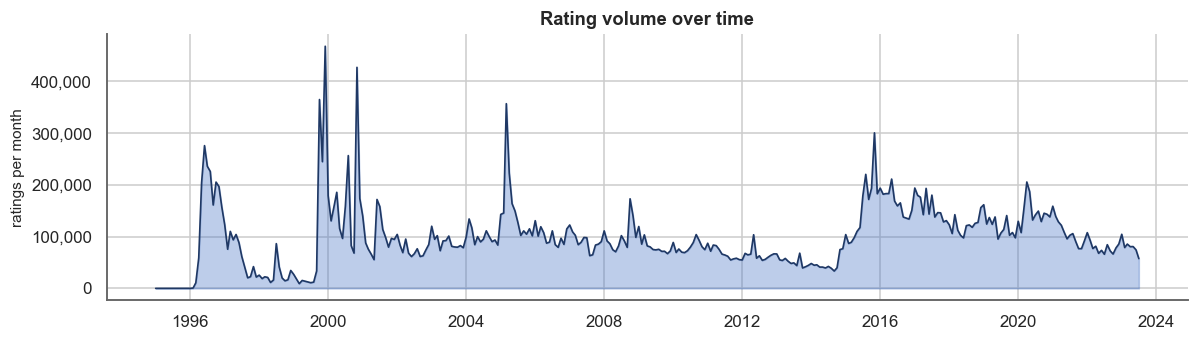

Rating activity is heavily non-stationary. A random train/test split would leak
future behaviour into the past; a temporal split is the defensible choice for the
held-out evaluation in Objective 7.


In [12]:
if RUN_RAW and ratings_path is not None:
    monthly = (lf.select(pl.from_epoch("timestamp", time_unit="s").alias("t"))
                 .group_by(pl.col("t").dt.truncate("1mo").alias("month"))
                 .len().sort("month").collect(engine="streaming").to_pandas())

    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.fill_between(monthly["month"], monthly["len"], color=ACCENT, alpha=0.35)
    ax.plot(monthly["month"], monthly["len"], color=INK, lw=1.1)
    ax.set_title("Rating volume over time")
    ax.set_ylabel("ratings per month"); ax.set_xlabel("")
    thousands(ax.yaxis)
    sns.despine()
    save_fig(fig, "a5_ratings_over_time")
    plt.show()

    print("Rating activity is heavily non-stationary. A random train/test split would leak")
    print("future behaviour into the past; a temporal split is the defensible choice for the")
    print("held-out evaluation in Objective 7.")

## A6. Free-text tags

  saved outputs\figures\a6_top_tags.png


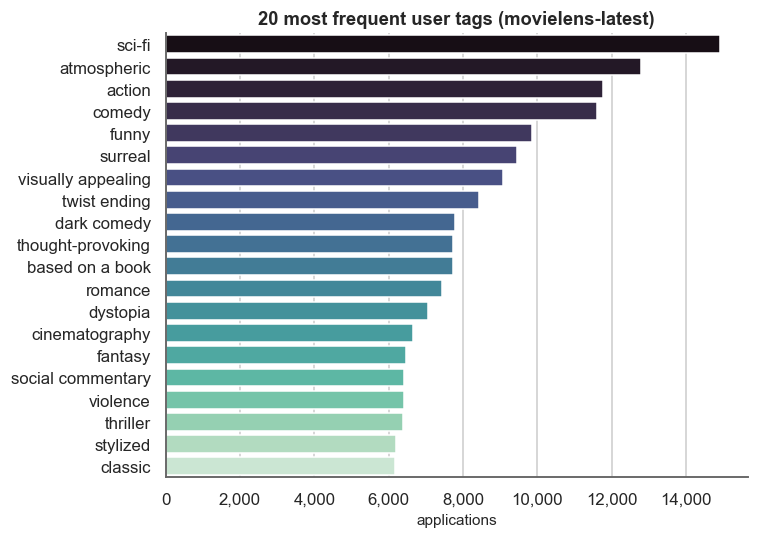

2,328,315 tag applications, 143,264 distinct tags, 53,452 films tagged


In [13]:
if RUN_RAW:
    tag_path = next((p for p in [RAW / "movielens-latest" / "tags.csv",
                                 RAW / "movielens-full" / "tags.csv"] if p.exists()), None)
    if tag_path:
        tags = pl.read_csv(tag_path, infer_schema_length=0).select(
            pl.col("movieId").cast(pl.Int32, strict=False),
            pl.col("tag").str.strip_chars().str.to_lowercase(),
        ).drop_nulls()
        top = tags.group_by("tag").len().sort("len", descending=True).head(20).to_pandas()

        fig, ax = plt.subplots(figsize=(7, 5))
        sns.barplot(top, y="tag", x="len", ax=ax, hue="tag", palette=SEQ, legend=False)
        ax.set_title(f"20 most frequent user tags ({tag_path.parent.name})")
        ax.set_xlabel("applications"); ax.set_ylabel("")
        thousands(ax.xaxis)
        sns.despine()
        save_fig(fig, "a6_top_tags")
        plt.show()

        print(f"{tags.height:,} tag applications, {tags['tag'].n_unique():,} distinct tags, "
              f"{tags['movieId'].n_unique():,} films tagged")

---
# Part B — the processed dataset

`movies_merged` is the output of `scripts/build_dataset.py`: one row per MovieLens `movieId`
across the union of both snapshots, with content resolved in tiers and provenance recorded per
row. This part asks what the merged table can actually support.

## B1. Shape and provenance

In [14]:
items = load_table("movies_merged")
print(f"\nshape: {items.height:,} rows x {items.width} columns")
print(f"in-memory: {items.estimated_size('mb'):,.0f} MB")

manifest_path = PROC / "build_manifest.json"
manifest = json.loads(manifest_path.read_text()) if manifest_path.exists() else None
if manifest:
    stats = manifest["statistics"]
    print(f"\nbuild config : ratings={manifest['config']['ratings_snapshot']}, "
          f"tier-2={manifest['config']['use_tmdb_dump']}, "
          f"format={manifest['config'].get('output_format', 'parquet')}")
    print(f"generated    : {manifest['generated_at_utc'][:19]} UTC")
    print(f"total ratings: {stats.get('total_ratings', 0):,} over "
          f"{stats.get('rated_films', 0):,} films")

loaded movies_merged from parquet

shape: 89,178 rows x 52 columns
in-memory: 78 MB

build config : ratings=movielens-latest, tier-2=True, format=parquet
generated    : 2026-08-22T18:07:40 UTC
total ratings: 33,832,162 over 83,239 films


In [15]:
schema_df = pd.DataFrame(
    [{"column": c, "dtype": str(t)} for c, t in items.schema.items()]
)
schema_df["group"] = np.select(
    [
        schema_df.column.isin(["movie_id", "tmdb_id", "imdb_id", "title_raw",
                               "title_clean", "release_year"]),
        schema_df.column.str.startswith(("has_", "in_ml")) | (schema_df.column == "content_source"),
        schema_df.dtype.str.startswith("List"),
        schema_df.column.str.startswith(("tmdb_", "ml_rating", "wr_", "weighted_")),
    ],
    ["identity", "provenance", "structured content", "demographic"],
    default="scalar content",
)
display(schema_df.groupby("group").agg(columns=("column", "count"),
                                       examples=("column", lambda s: ", ".join(s[:4]))))

,columns,examples
group,,
demographic,13,"tmdb_vote_average, tmdb_vote_count, tmdb_popul..."
identity,6,"movie_id, tmdb_id, imdb_id, title_raw"
provenance,8,"in_ml_full, in_ml_latest, content_source, has_..."
scalar content,17,"overview_text, tagline, original_title, origin..."
structured content,8,"genres, keywords, cast_top, directors"


  saved outputs\figures\b1_content_provenance.png


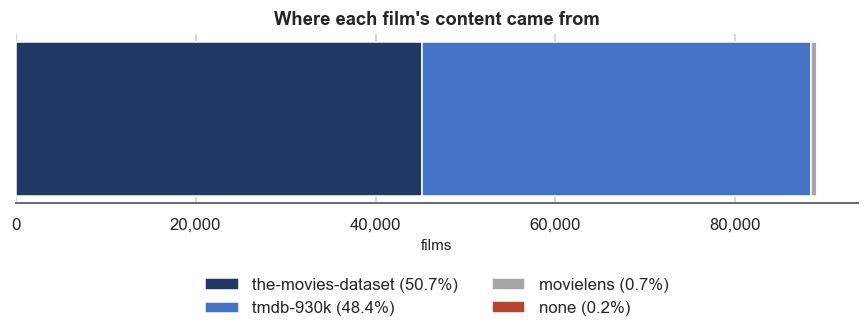

,content_source,len,share
0,the-movies-dataset,45208,0.506941
1,tmdb-930k,43166,0.484043
2,movielens,668,0.007491
3,none,136,0.001525


In [16]:
prov = (items.group_by("content_source").len()
             .sort("len", descending=True).to_pandas())
prov["share"] = prov["len"] / items.height

fig, ax = plt.subplots(figsize=(8, 3))
left = 0
palette = {"the-movies-dataset": INK, "tmdb-930k": ACCENT,
           "movielens": MUTED, "none": NEG}
for _, r in prov.iterrows():
    ax.barh(0, r["len"], left=left, color=palette.get(r["content_source"], MUTED),
            edgecolor="white", label=f"{r['content_source']} ({r['share']:.1%})")
    left += r["len"]
ax.set_yticks([]); ax.set_xlabel("films"); thousands(ax.xaxis)
ax.set_title("Where each film's content came from")
ax.legend(frameon=False, ncols=2, loc="upper center", bbox_to_anchor=(0.5, -0.35))
sns.despine(left=True)
save_fig(fig, "b1_content_provenance")
plt.show()
display(prov)

## B2. Coverage — what each recommender module can actually address

`has_content` is the loosest possible test: a film passes if it has genres. The figures that
constrain the three modules are the specific ones.

  saved outputs\figures\b2_feature_coverage.png


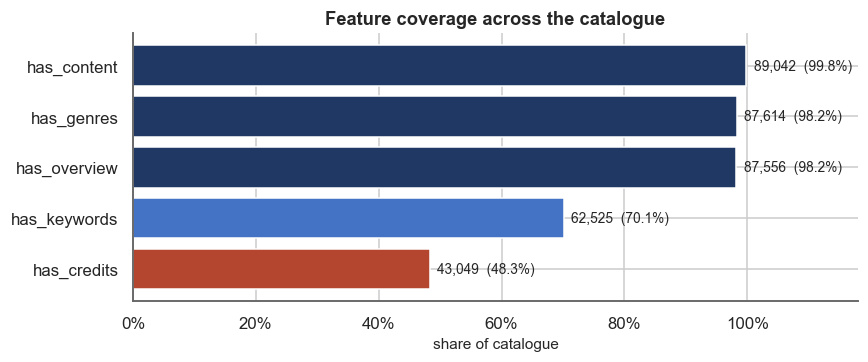

Module ceilings implied by the above:
  plot module      -> 87,556 films
  metadata module  -> 34,722 films with BOTH cast and keywords (its full feature vector)
  cold-start floor -> 136 films no content method can rank


In [17]:
flags = [c for c in items.columns if c.startswith("has_")]
cov = pd.DataFrame({
    "films": [int(items[c].sum()) for c in flags],
}, index=flags)
cov["share"] = cov["films"] / items.height
cov = cov.sort_values("films", ascending=False)

fig, ax = plt.subplots(figsize=(8, 3.4))
bars = ax.barh(cov.index, cov["share"], color=[INK if s > .9 else ACCENT if s > .6 else NEG
                                               for s in cov["share"]])
for bar, (n, s) in zip(bars, cov[["films", "share"]].values):
    ax.text(s + .012, bar.get_y() + bar.get_height() / 2,
            f"{int(n):,}  ({s:.1%})", va="center", fontsize=9)
ax.set_xlim(0, 1.18); ax.set_xlabel("share of catalogue"); ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Feature coverage across the catalogue")
ax.invert_yaxis()
sns.despine()
save_fig(fig, "b2_feature_coverage")
plt.show()

print("Module ceilings implied by the above:")
print(f"  plot module      -> {int(items['has_overview'].sum()):,} films")
print(f"  metadata module  -> {int((items['has_credits'] & items['has_keywords']).sum()):,} "
      "films with BOTH cast and keywords (its full feature vector)")
print(f"  cold-start floor -> {int((~items['has_content']).sum()):,} films no content method can rank")

  saved outputs\figures\b2_joint_availability.png


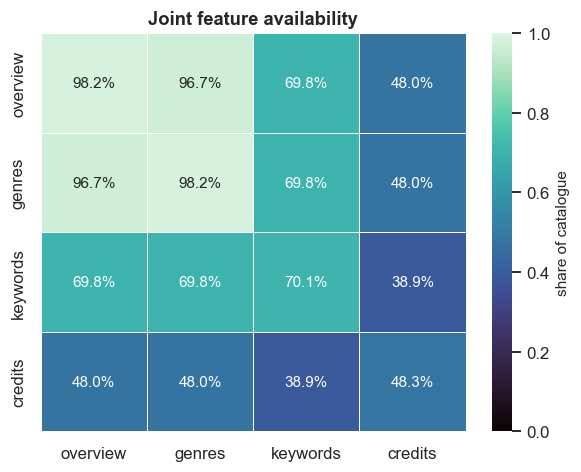

In [18]:
# Which feature combinations actually co-occur? A missingness co-occurrence matrix is more
# informative here than a per-column null count, because the modules need combinations.
core = ["has_overview", "has_genres", "has_keywords", "has_credits"]
mat = np.zeros((len(core), len(core)))
for i, a in enumerate(core):
    for j, b in enumerate(core):
        mat[i, j] = float((items[a] & items[b]).sum()) / items.height

fig, ax = plt.subplots(figsize=(5.4, 4.4))
sns.heatmap(mat, annot=True, fmt=".1%", cmap=SEQ, vmin=0, vmax=1,
            xticklabels=[c.replace("has_", "") for c in core],
            yticklabels=[c.replace("has_", "") for c in core],
            cbar_kws={"label": "share of catalogue"}, ax=ax, linewidths=.5)
ax.set_title("Joint feature availability")
save_fig(fig, "b2_joint_availability")
plt.show()

## B3. Genres

  saved outputs\figures\b3_genres.png


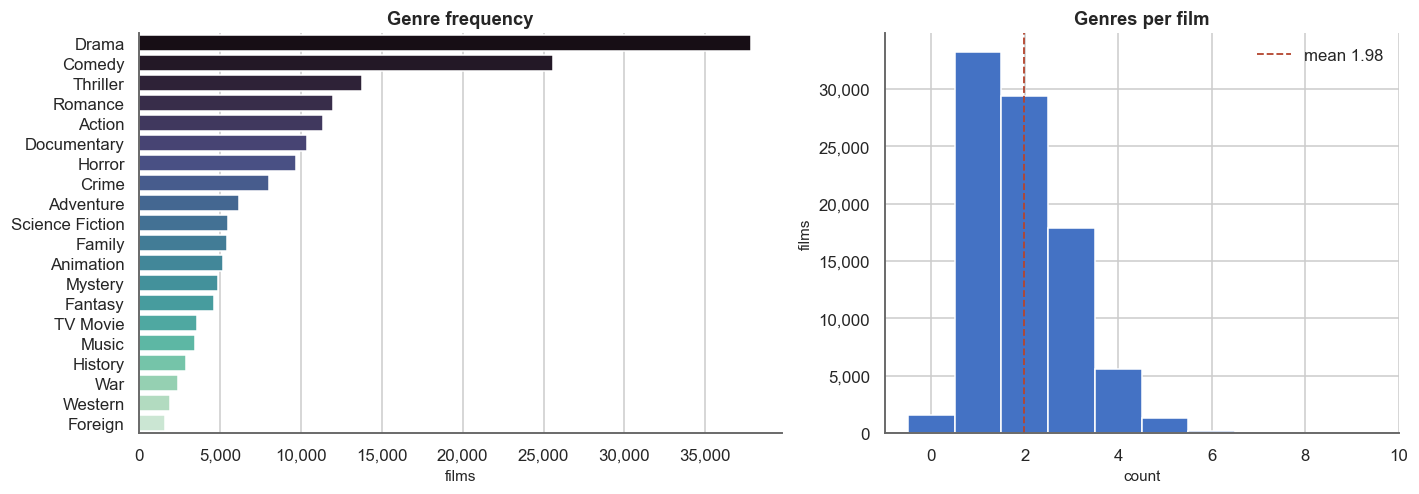

25 distinct genres; 1,564 films carry none


In [19]:
genre_counts = (items.select(pl.col("genres").explode().drop_nulls().alias("genre"))
                     .group_by("genre").len().sort("len", descending=True).to_pandas())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6),
                         gridspec_kw={"width_ratios": [1.25, 1]})
sns.barplot(genre_counts.head(20), y="genre", x="len", ax=axes[0],
            hue="genre", palette=SEQ, legend=False)
axes[0].set_title("Genre frequency"); axes[0].set_xlabel("films"); axes[0].set_ylabel("")
thousands(axes[0].xaxis)

per_film = items["genres"].list.len().to_numpy()
axes[1].hist(per_film, bins=range(0, per_film.max() + 2), color=ACCENT, align="left")
axes[1].set_title("Genres per film")
axes[1].set_xlabel("count"); axes[1].set_ylabel("films")
axes[1].axvline(per_film.mean(), color=NEG, ls="--", lw=1.2,
                label=f"mean {per_film.mean():.2f}")
axes[1].legend(frameon=False)
thousands(axes[1].yaxis)
sns.despine()
save_fig(fig, "b3_genres")
plt.show()

print(f"{len(genre_counts)} distinct genres; "
      f"{(per_film == 0).sum():,} films carry none")

  saved outputs\figures\b3_genre_cooccurrence.png


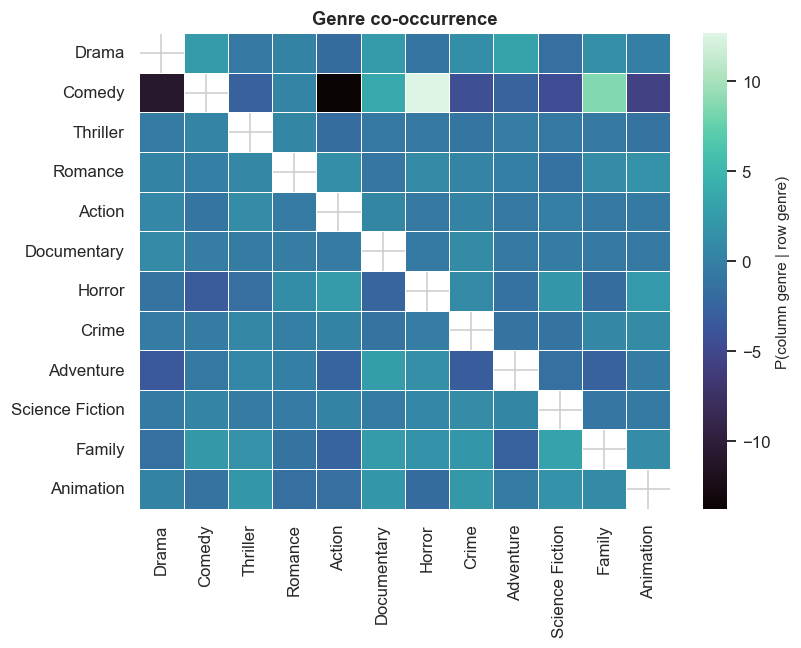

In [20]:
# Genre co-occurrence, restricted to the 12 most common so the matrix stays readable.
# Built as a binary indicator matrix and a single matmul rather than a nested loop
# over 89k films.
top_genres = genre_counts.head(12)["genre"].tolist()
indicator = items.select([
    pl.col("genres").list.contains(g).cast(pl.Int8).alias(g) for g in top_genres
]).to_numpy()

co = pd.DataFrame(indicator.T @ indicator, index=top_genres,
                  columns=top_genres, dtype=float)
norm = co.div(np.diag(co), axis=0)          # P(column genre | row genre)
norm = norm.mask(np.eye(len(norm), dtype=bool))  # blank the diagonal (always 1.0)

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(norm, cmap=SEQ, annot=False, linewidths=.4,
            cbar_kws={"label": "P(column genre | row genre)"}, ax=ax)
ax.set_title("Genre co-occurrence")
save_fig(fig, "b3_genre_cooccurrence")
plt.show()

## B4. Release years and catalogue composition

  saved outputs\figures\b4_release_years.png


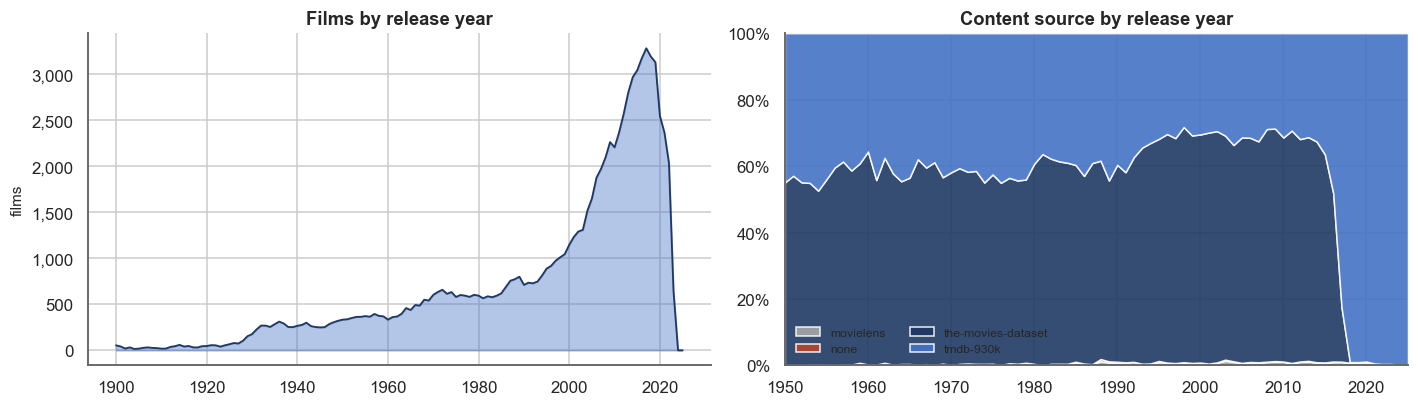

median release year: 2006; films missing a year: 132


In [21]:
yr = items.filter(pl.col("release_year").is_between(1900, 2026))
by_year = yr.group_by("release_year").len().sort("release_year").to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].fill_between(by_year["release_year"], by_year["len"], color=ACCENT, alpha=.4)
axes[0].plot(by_year["release_year"], by_year["len"], color=INK, lw=1.2)
axes[0].set_title("Films by release year"); axes[0].set_xlabel("")
axes[0].set_ylabel("films"); thousands(axes[0].yaxis)

src_year = (yr.group_by(["release_year", "content_source"]).len()
              .sort("release_year").to_pandas()
              .pivot(index="release_year", columns="content_source", values="len").fillna(0))
src_year = src_year.loc[src_year.index >= 1950]
share = src_year.div(src_year.sum(axis=1), axis=0)
axes[1].stackplot(share.index, *[share[c] for c in share.columns],
                  labels=share.columns,
                  colors=[palette.get(c, MUTED) for c in share.columns], alpha=.9)
axes[1].set_title("Content source by release year")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_xlim(1950, share.index.max()); axes[1].set_ylim(0, 1)
axes[1].legend(frameon=False, fontsize=8, loc="lower left", ncols=2)
sns.despine()
save_fig(fig, "b4_release_years")
plt.show()

print(f"median release year: {int(yr['release_year'].median())}; "
      f"films missing a year: {int(items['release_year'].null_count()):,}")

## B5. Popularity and the demographic module

  saved outputs\figures\b5_popularity.png


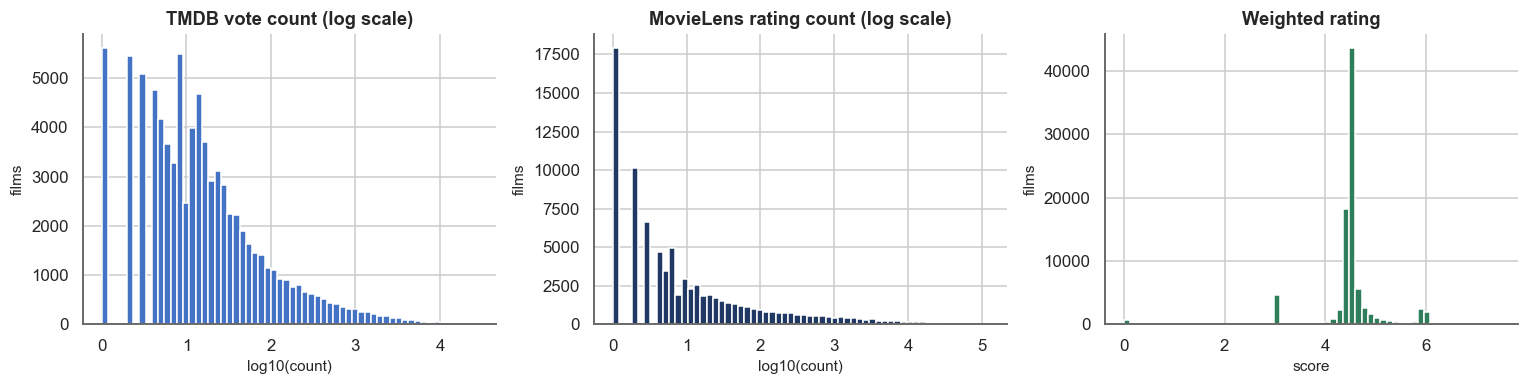

,weighted_rating_source,len,share
0,blended,78418,0.879342
1,tmdb_wr,5060,0.056740
2,movielens_wr,4821,0.054060
3,raw_tmdb_mean,763,0.008556
4,none,116,0.001301



weighted-rating constants from the build manifest:
  C_movielens    3.0127060989851273
  C_tmdb         5.962089094003453
  m_movielens    263.0
  m_tmdb         140.0
  quantile       0.9


In [22]:
num = items.select("tmdb_vote_count", "tmdb_vote_average", "ml_rating_count",
                   "ml_rating_mean", "weighted_rating", "runtime_minutes",
                   "budget", "revenue").to_pandas()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, col, colour, title in [
    (axes[0], "tmdb_vote_count", ACCENT, "TMDB vote count"),
    (axes[1], "ml_rating_count", INK, "MovieLens rating count"),
]:
    d = num[col].dropna()
    d = d[d > 0]
    ax.hist(np.log10(d), bins=60, color=colour)
    ax.set_title(f"{title} (log scale)"); ax.set_xlabel("log10(count)")
    ax.set_ylabel("films")

axes[2].hist(num["weighted_rating"].dropna(), bins=60, color=POS)
axes[2].set_title("Weighted rating"); axes[2].set_xlabel("score"); axes[2].set_ylabel("films")
sns.despine()
save_fig(fig, "b5_popularity")
plt.show()

wr_src = items.group_by("weighted_rating_source").len().sort("len", descending=True).to_pandas()
wr_src["share"] = wr_src["len"] / items.height
display(wr_src)
if manifest:
    print("\nweighted-rating constants from the build manifest:")
    for k, v in manifest["statistics"]["weighted_rating_constants"].items():
        print(f"  {k:14} {v}")

  saved outputs\figures\b5_weighted_rating_shrinkage.png


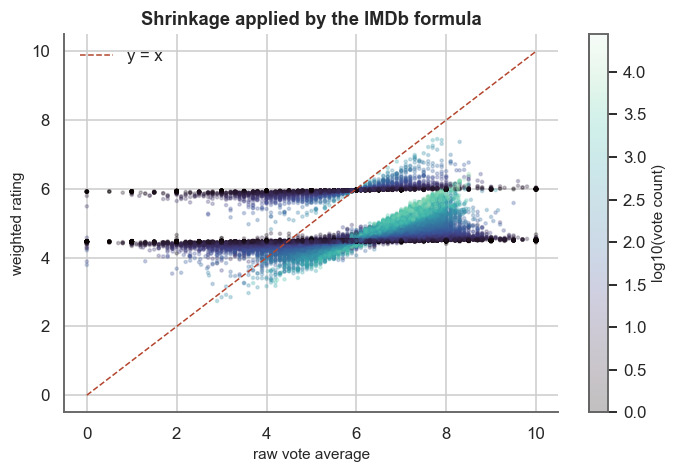

Top 10 by weighted rating (vote_count > 500):


,title_clean,tmdb_vote_average,tmdb_vote_count,weighted_rating
0,Mary and Max,7.800,596.0,7.450397
1,"Best Offer, The (Migliore offerta, La)",7.700,719.0,7.416755
2,Serial (Bad) Weddings (Qu'est-ce Qu'on An Fit ...,6.900,1114.0,6.795290
3,The Lion King II: Simba's Pride,6.700,1034.0,6.612004
4,The Babadook,6.500,1890.0,6.462903
5,The Shawshank Redemption,8.500,8358.0,6.435984
6,Parasite,8.515,16430.0,6.398008
7,The Godfather,8.500,6024.0,6.382185
8,Spider-Man: Into the Spider-Verse,8.404,14024.0,6.272047
9,Fight Club,8.300,9678.0,6.249480


In [23]:
# Does the weighted rating actually reorder the catalogue, or is it just vote_average?
sub = items.filter(pl.col("tmdb_vote_count") > 0).select(
    "title_clean", "tmdb_vote_average", "tmdb_vote_count", "weighted_rating").to_pandas()

fig, ax = plt.subplots(figsize=(6.4, 4.4))
sc = ax.scatter(sub["tmdb_vote_average"], sub["weighted_rating"],
                c=np.log10(sub["tmdb_vote_count"].clip(lower=1)),
                s=4, alpha=.25, cmap=SEQ)
ax.plot([0, 10], [0, 10], color=NEG, ls="--", lw=1, label="y = x")
ax.set_xlabel("raw vote average"); ax.set_ylabel("weighted rating")
ax.set_title("Shrinkage applied by the IMDb formula")
plt.colorbar(sc, ax=ax, label="log10(vote count)")
ax.legend(frameon=False)
sns.despine()
save_fig(fig, "b5_weighted_rating_shrinkage")
plt.show()

print("Top 10 by weighted rating (vote_count > 500):")
display(sub[sub.tmdb_vote_count > 500].nlargest(10, "weighted_rating")
           .reset_index(drop=True))

### Scale consistency of the blended weighted rating

`weighted_rating` combines two source scales. Whenever a score is built from more than one
rating system, the ranges have to be checked explicitly: a blend of incompatible scales fails
silently, producing a column that looks plausible and ranks wrongly.

,min,max,mean
tmdb_vote_average,0.0,10.0,5.632
ml_rating_mean,0.5,5.0,3.013


Any blend of the two is only meaningful once they are mapped to a common range.


,weighted_rating_source,films,mean_wr
0,none,116,NaN
1,tmdb_wr,5060,5.955253
2,blended,78418,4.534207
3,movielens_wr,4821,3.018363
4,raw_tmdb_mean,763,0.018349


  saved outputs\figures\b5_weighted_rating_by_source.png


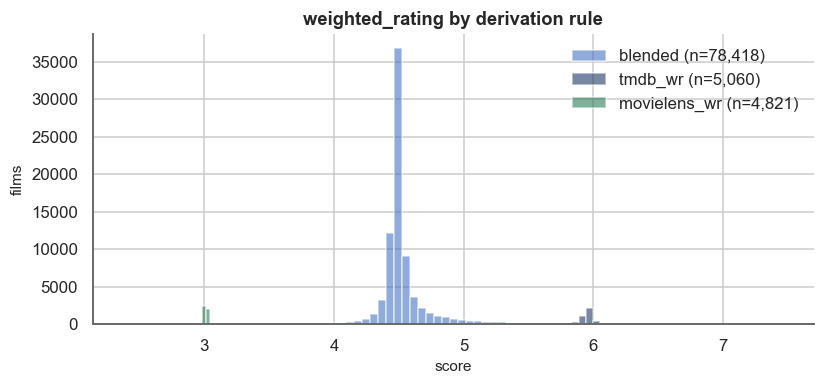


Highest weighted_rating among the most-rated films (ml_rating_count > 20,000):


,title_clean,tmdb_vote_average,ml_rating_mean,wr_tmdb,wr_ml,weighted_rating
0,The Shawshank Redemption,8.5,4.417,8.458,4.414,6.436
1,The Godfather,8.5,4.327,8.442,4.322,6.382
2,Fight Club,8.3,4.236,8.267,4.232,6.249
3,The Godfather: Part II,8.3,4.270,8.208,4.263,6.235
4,Schindler's List,8.3,4.242,8.228,4.239,6.233


Compare against films scored from TMDB votes alone. If well-known titles rank below
obscure ones, the blend is mixing scales rather than measuring quality.


In [24]:
scales = pd.DataFrame({
    "min": [items["tmdb_vote_average"].min(), items["ml_rating_mean"].min()],
    "max": [items["tmdb_vote_average"].max(), items["ml_rating_mean"].max()],
    "mean": [items["tmdb_vote_average"].mean(), items["ml_rating_mean"].mean()],
}, index=["tmdb_vote_average", "ml_rating_mean"]).round(3)
display(scales)

lo, hi = scales.loc["tmdb_vote_average", "max"], scales.loc["ml_rating_mean", "max"]
if abs(lo - hi) > 1e-6:
    print(f"WARNING: source scales differ (TMDB tops out at {lo:g}, MovieLens at {hi:g}).")
    print("Any blend of the two is only meaningful once they are mapped to a common range.")

by_src = (items.group_by("weighted_rating_source")
               .agg(pl.len().alias("films"),
                    pl.col("weighted_rating").mean().alias("mean_wr"))
               .sort("mean_wr", descending=True).to_pandas())
display(by_src)

fig, ax = plt.subplots(figsize=(7.6, 3.6))
for src, colour in [("blended", ACCENT), ("tmdb_wr", INK), ("movielens_wr", POS)]:
    vals = items.filter(pl.col("weighted_rating_source") == src)["weighted_rating"].drop_nulls()
    if len(vals):
        ax.hist(vals.to_numpy(), bins=60, alpha=.6, label=f"{src} (n={len(vals):,})", color=colour)
ax.set_title("weighted_rating by derivation rule")
ax.set_xlabel("score"); ax.set_ylabel("films")
ax.legend(frameon=False)
sns.despine()
save_fig(fig, "b5_weighted_rating_by_source")
plt.show()

print("\nHighest weighted_rating among the most-rated films (ml_rating_count > 20,000):")
display(items.filter(pl.col("ml_rating_count") > 20_000)
             .sort("weighted_rating", descending=True).head(5)
             .select("title_clean", "tmdb_vote_average", "ml_rating_mean",
                     "wr_tmdb", "wr_ml", "weighted_rating").to_pandas().round(3))
print("Compare against films scored from TMDB votes alone. If well-known titles rank below")
print("obscure ones, the blend is mixing scales rather than measuring quality.")

## B6. Text features

  saved outputs\figures\b6_text_lengths.png


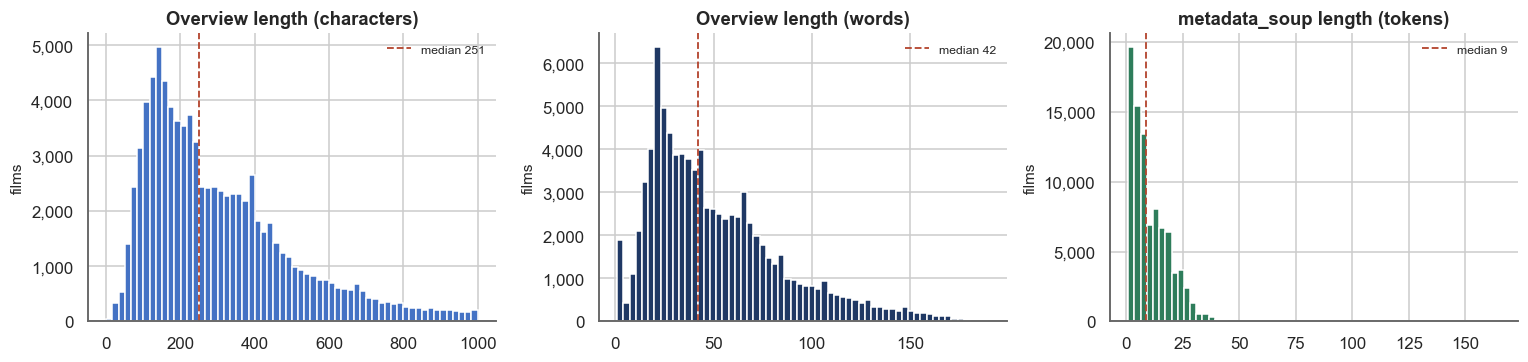

films with an empty overview      : 1,617
films with an empty metadata_soup : 6,963
overviews under 20 words          : 12,763  (weak input for TF-IDF)


In [25]:
text = items.select(
    pl.col("overview_text").fill_null("").str.len_chars().alias("overview_chars"),
    pl.col("overview_text").fill_null("").str.split(" ").list.len().alias("overview_words"),
    pl.col("metadata_soup").fill_null("").str.split(" ").list.len().alias("soup_tokens"),
).to_pandas()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
for ax, col, colour, title in [
    (axes[0], "overview_chars", ACCENT, "Overview length (characters)"),
    (axes[1], "overview_words", INK, "Overview length (words)"),
    (axes[2], "soup_tokens", POS, "metadata_soup length (tokens)"),
]:
    d = text[col][text[col] > 0]
    ax.hist(d, bins=60, color=colour)
    ax.axvline(d.median(), color=NEG, ls="--", lw=1.2, label=f"median {d.median():.0f}")
    ax.set_title(title); ax.set_ylabel("films"); ax.set_xlabel("")
    ax.legend(frameon=False, fontsize=8)
    thousands(ax.yaxis)
sns.despine()
save_fig(fig, "b6_text_lengths")
plt.show()

print(f"films with an empty overview      : {int((text.overview_chars == 0).sum()):,}")
print(f"films with an empty metadata_soup : {int((text.soup_tokens <= 1).sum()):,}")
print(f"overviews under 20 words          : {int((text.overview_words < 20).sum()):,}"
      "  (weak input for TF-IDF)")

  saved outputs\figures\b6_overview_wordcloud.png


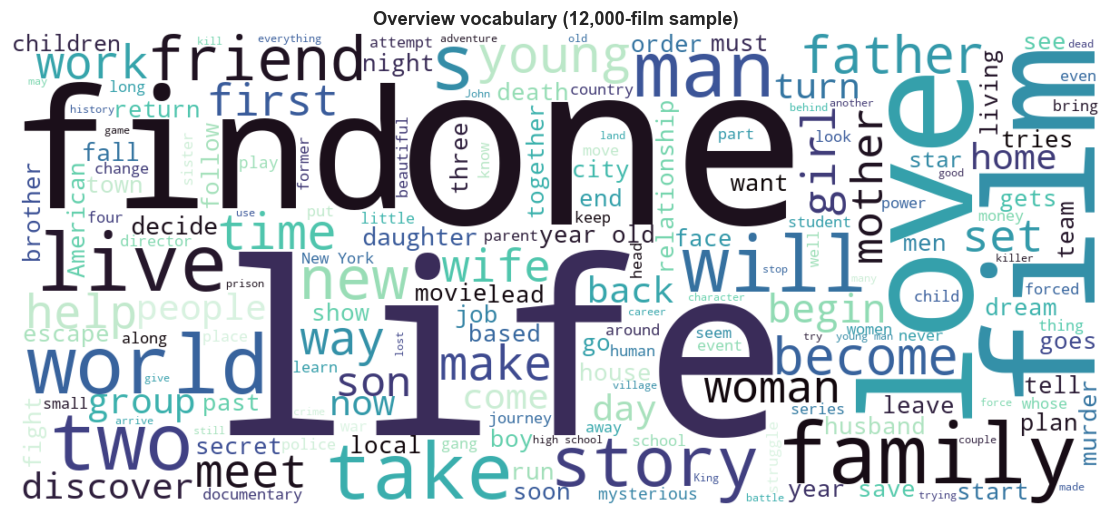

In [26]:
from wordcloud import WordCloud

sample = " ".join(
    items.filter(pl.col("has_overview"))
         .select("overview_text").sample(min(12_000, int(items["has_overview"].sum())), seed=7)
         .to_series().to_list()
)
wc = WordCloud(width=1200, height=520, background_color="white",
               colormap="mako", max_words=180, random_state=7).generate(sample)

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
ax.set_title("Overview vocabulary (12,000-film sample)")
save_fig(fig, "b6_overview_wordcloud")
plt.show()

## B7. Cast, directors and keywords — the long tail

  saved outputs\figures\b7_entity_long_tails.png


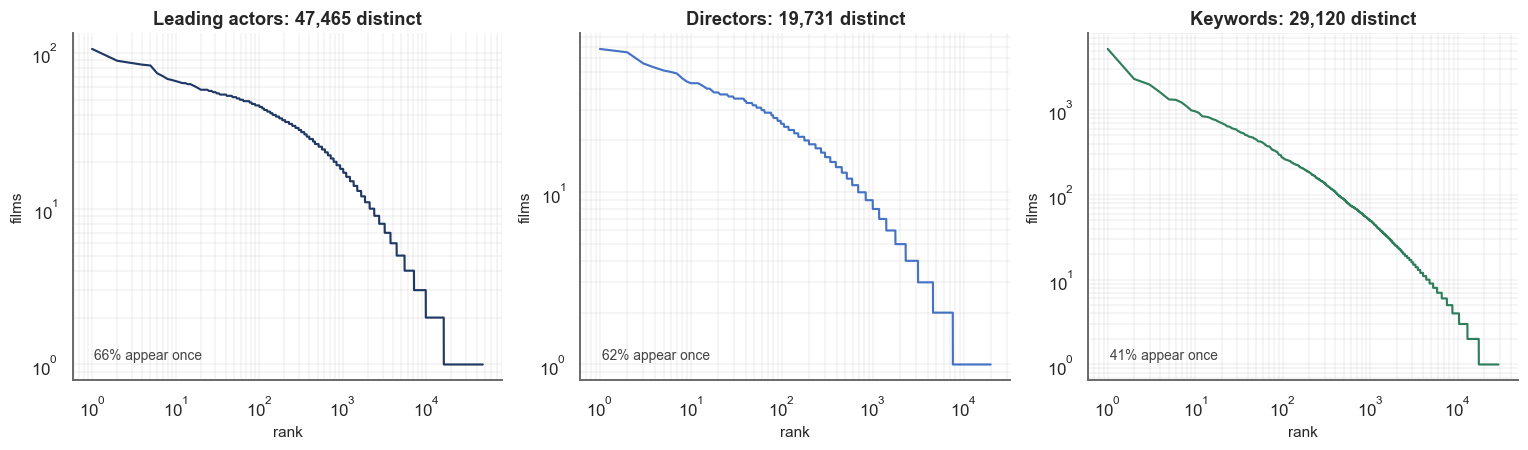

Entities appearing on a single film carry no similarity signal but inflate the
vocabulary. This motivates a min_df threshold in the feature-engineering notebook.


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, col, title, colour in [
    (axes[0], "cast_top", "Leading actors", INK),
    (axes[1], "directors", "Directors", ACCENT),
    (axes[2], "keywords", "Keywords", POS),
]:
    counts = (items.select(pl.col(col).explode().drop_nulls().alias("v"))
                   .group_by("v").len().sort("len", descending=True).to_pandas())
    ax.loglog(np.arange(1, len(counts) + 1), counts["len"], color=colour, lw=1.4)
    ax.set_title(f"{title}: {len(counts):,} distinct")
    ax.set_xlabel("rank"); ax.set_ylabel("films")
    ax.grid(True, which="both", alpha=.25)
    singletons = int((counts["len"] == 1).sum())
    ax.text(.05, .06, f"{singletons / len(counts):.0%} appear once",
            transform=ax.transAxes, fontsize=9, color="#444444")
sns.despine()
save_fig(fig, "b7_entity_long_tails")
plt.show()

print("Entities appearing on a single film carry no similarity signal but inflate the")
print("vocabulary. This motivates a min_df threshold in the feature-engineering notebook.")

In [28]:
for col, label in [("cast_top", "actors"), ("directors", "directors"), ("keywords", "keywords")]:
    top = (items.select(pl.col(col).explode().drop_nulls().alias("v"))
                .group_by("v").len().sort("len", descending=True).head(8).to_pandas())
    print(f"\nmost frequent {label}:")
    print("  " + ", ".join(f"{r.v} ({r.len})" for r in top.itertuples()))


most frequent actors:
  John Wayne (106), Jackie Chan (89), Michael Caine (86), Robert De Niro (84), Gérard Depardieu (83), Christopher Lee (74), Nicolas Cage (71), Bette Davis (68)

most frequent directors:
  John Ford (68), Michael Curtiz (65), Werner Herzog (56), Alfred Hitchcock (53), Georges Méliès (51), Jean-Luc Godard (50), Woody Allen (49), Sidney Lumet (46)

most frequent keywords:
  woman director (5227), murder (2316), independent film (1990), short film (1601), based on novel or book (1329), biography (1314), musical (1221), revenge (1099)


## B8. Numeric structure

  saved outputs\figures\b8_numeric_correlation.png


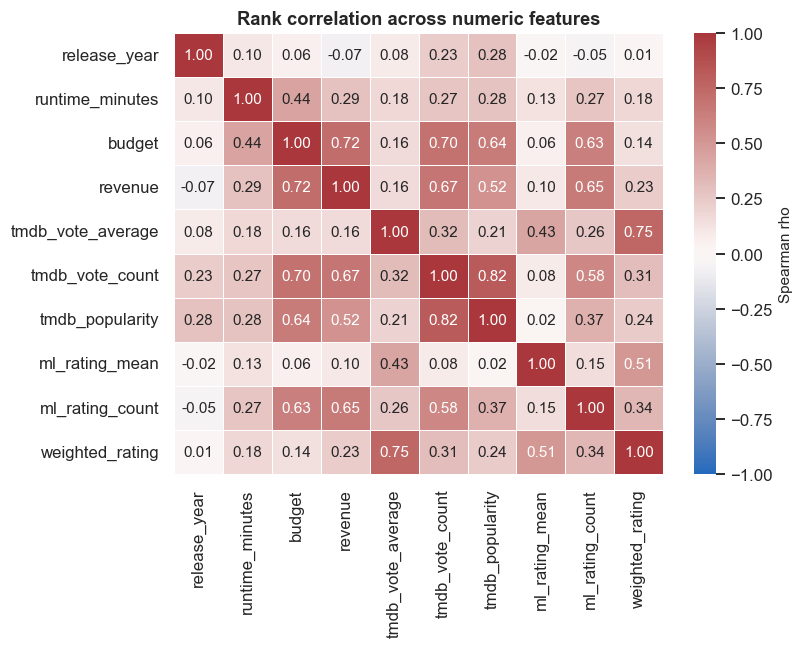

,count,mean,50%,std,min,max
release_year,89046.0,1.995379e+03,2.006000e+03,2.578210e+01,1874.0,2.029000e+03
runtime_minutes,88377.0,9.005849e+01,9.300000e+01,5.640553e+01,0.0,1.248000e+04
budget,12742.0,1.919641e+07,5.891844e+06,3.484794e+07,1.0,5.000000e+08
revenue,10261.0,6.276531e+07,1.097230e+07,1.511220e+08,1.0,2.800000e+09
tmdb_vote_average,88384.0,5.631825e+00,6.000000e+00,1.859619e+00,0.0,1.000000e+01
tmdb_vote_count,88384.0,1.035377e+02,1.000000e+01,5.558080e+02,0.0,2.771300e+04
tmdb_popularity,88384.0,3.787788e+00,1.705000e+00,1.353474e+01,0.0,1.458514e+03
ml_rating_mean,83239.0,3.012706e+00,3.083333e+00,7.908720e-01,0.5,5.000000e+00
ml_rating_count,83239.0,4.064460e+02,5.000000e+00,2.806976e+03,1.0,1.222960e+05
weighted_rating,89062.0,4.494202e+00,4.492101e+00,6.717241e-01,0.0,7.450397e+00



budget present  : 12,742 films
revenue present : 10,261 films


In [29]:
corr_cols = ["release_year", "runtime_minutes", "budget", "revenue",
             "tmdb_vote_average", "tmdb_vote_count", "tmdb_popularity",
             "ml_rating_mean", "ml_rating_count", "weighted_rating"]
cdf = items.select(corr_cols).to_pandas()
# Budget and revenue use 0 as a missing sentinel; treating them as real zeroes
# would distort every correlation they appear in.
cdf[["budget", "revenue"]] = cdf[["budget", "revenue"]].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(7.4, 6))
sns.heatmap(cdf.corr(method="spearman"), annot=True, fmt=".2f", cmap="vlag",
            center=0, vmin=-1, vmax=1, linewidths=.4, ax=ax,
            cbar_kws={"label": "Spearman rho"})
ax.set_title("Rank correlation across numeric features")
save_fig(fig, "b8_numeric_correlation")
plt.show()

display(cdf.describe().T[["count", "mean", "50%", "std", "min", "max"]])
print(f"\nbudget present  : {int(cdf.budget.notna().sum()):,} films")
print(f"revenue present : {int(cdf.revenue.notna().sum()):,} films")

## B9. The cold-start population

  saved outputs\figures\b9_cold_start_segments.png


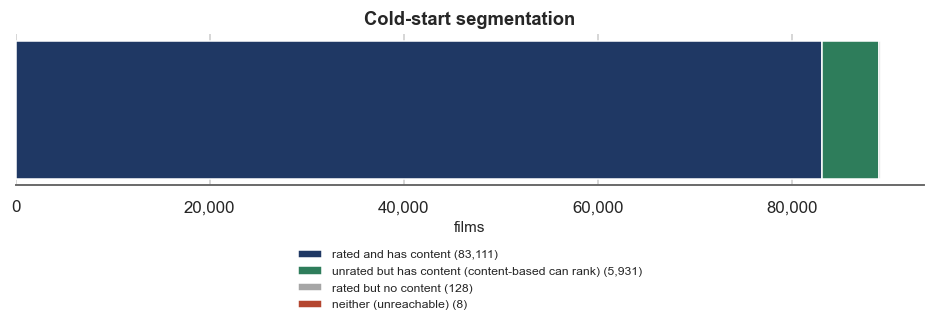

,films,share
rated and has content,83111,0.931968
unrated but has content (content-based can rank),5931,0.066507
rated but no content,128,0.001435
neither (unreachable),8,0.000090


In [30]:
cold = items.with_columns(
    (pl.col("ml_rating_count").fill_null(0) == 0).alias("no_ratings"),
    (~pl.col("has_content")).alias("no_content"),
)
seg = pd.Series({
    "rated and has content": int((~cold["no_ratings"] & ~cold["no_content"]).sum()),
    "unrated but has content (content-based can rank)":
        int((cold["no_ratings"] & ~cold["no_content"]).sum()),
    "rated but no content": int((~cold["no_ratings"] & cold["no_content"]).sum()),
    "neither (unreachable)": int((cold["no_ratings"] & cold["no_content"]).sum()),
}, name="films")

fig, ax = plt.subplots(figsize=(8.6, 2.9))
left = 0
for (label, value), colour in zip(seg.items(), [INK, POS, MUTED, NEG]):
    ax.barh(0, value, left=left, color=colour, edgecolor="white", label=f"{label} ({value:,})")
    left += value
ax.set_yticks([]); ax.set_xlabel("films"); thousands(ax.xaxis)
ax.set_title("Cold-start segmentation")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.35), fontsize=8)
sns.despine(left=True)
save_fig(fig, "b9_cold_start_segments")
plt.show()
display(seg.to_frame().assign(share=lambda d: d.films / items.height))

## B10. Interactions

In [31]:
inter = load_table("interactions", lazy=True)
isum = inter.select(
    pl.len().alias("interactions"),
    pl.col("user_id").n_unique().alias("users"),
    pl.col("movie_id").n_unique().alias("films"),
    pl.col("rating").mean().alias("mean_rating"),
).collect(engine="streaming")
display(isum.to_pandas().T.rename(columns={0: "value"}))

orphans = (inter.select("movie_id").unique()
                .join(items.lazy().select("movie_id"), on="movie_id", how="anti")
                .select(pl.len()).collect(engine="streaming").item())
print(f"\ninteractions referencing films absent from the item table: {orphans}")
print("Zero is the expected result: the pipeline filters them by default so that recall@k")
print("and NDCG@k are not depressed by items that can never be retrieved.")

loaded interactions from parquet


ComputeError: parquet: File out of specification: The file must end with PAR1

---
## Findings

Recorded here so the write-up can cite the notebook rather than re-deriving them.

1. **The two MovieLens snapshots are mutually consistent.** Zero title, genre or IMDb-id
   conflicts across the shared films. The union is safe, and the older extract contributes
   films the newer one lacks.
2. **The tier-2 TMDB dump does most of the work on coverage.** Roughly half the catalogue takes
   its content from the 930k dump rather than The Movies Dataset, which lifts overview coverage
   from about half the catalogue to nearly all of it.
3. **Cast remains the binding constraint.** Only The Movies Dataset carries cast and crew, so
   the metadata module's full feature vector is available for a much smaller population than
   the plot module's. Any comparison between textual and structured features has to control
   for this or it measures coverage rather than representation.
4. **Ratings are extremely sparse and strongly non-stationary.** A temporal split is the
   defensible choice for the held-out evaluation.
5. **Entity vocabularies have heavy tails.** A large share of actors, directors and keywords
   appear on exactly one film, contributing vocabulary without similarity signal, which argues
   for a `min_df` threshold during vectorisation.
6. **Budget and revenue use zero as a missing sentinel.** They must be treated as missing
   before any correlation or scaling, otherwise both are badly distorted.

Next: `02_feature_engineering.ipynb`.